# Notebook 04 — Etiquetado Multilabel y Preparación de Dataset

**Fase 2 · Módulo 2D** — Etiquetado multilabel derivado de comentarios IDEXX, split temporal y preparación del dataset para modelado supervisado.

**Entrada:** `data/interim/featured_raw.csv` (3.755 registros: 2.454 IDEXX + 1.301 DAP)  
**Salida:** `data/processed/labeled_idexx.csv`, `train.csv`, `val.csv`, `test.csv`, `feature_columns.json`, `label_columns.json`

| Sección | Contenido |
|---|---|
| **0** | Dependencias y configuración |
| **1** | Carga, verificación de features y separación IDEXX |
| **2** | Definición de la taxonomía de etiquetas (8 oficiales + QC) |
| **3** | Función de etiquetado multilabel vía regex sobre `idexx_comments` |
| **4** | Análisis de co-ocurrencia de etiquetas |
| **5** | Split temporal 70/15/15 (por batch cronológico) |
| **6** | Visualización de distribución temporal y desbalance |
| **7** | Definición del feature set canónico (38 features) y exclusiones |
| **8** | Imputación de valores faltantes (mediana, fit en train) |
| **9** | Guardado de splits y artefactos de configuración |
| **10–11** | Verificación de integridad y resumen |


### Guia rapida del codigo

- Usa `featured_raw.csv` y conserva IDEXX para entrenar etiquetas supervisadas.
- Define la taxonomia multilabel desde comentarios del laboratorio.
- Separa train/val/test por fecha y calcula medianas de imputacion solo con train.
- Exporta splits, columnas de features, columnas de labels y distribuciones en `data/processed/`.


## 0. Dependencias y configuracion

In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.impute import SimpleImputer
from IPython.display import display, Image
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["savefig.dpi"]   = 150
plt.rcParams["figure.figsize"] = (12, 6)

def save_and_show(fig, filename, outputs_dir=None):
    """Guarda la figura en disco y la muestra inline en el notebook."""
    if outputs_dir is None:
        outputs_dir = OUTPUTS
    path = outputs_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))
    print(f"  [Guardada] {filename}")

# Rutas del proyecto
_cwd = Path.cwd()
PROJECT_ROOT = _cwd
while PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "scripts").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if not ((PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "scripts").exists()):
    raise RuntimeError(f"No se localizo la raiz del proyecto (data/ y scripts/). CWD: {_cwd}")

DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS        = PROJECT_ROOT / "outputs"

for d in [DATA_PROCESSED, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Raiz del proyecto : {PROJECT_ROOT}")
print(f"Datos intermedios : {DATA_INTERIM}")
print(f"Datos procesados  : {DATA_PROCESSED}")
print(f"Salidas graficas  : {OUTPUTS}")

Raiz del proyecto : /home/edwinb/tesis/hemogramas-proyectoICC
Datos intermedios : /home/edwinb/tesis/hemogramas-proyectoICC/data/interim
Datos procesados  : /home/edwinb/tesis/hemogramas-proyectoICC/data/processed
Salidas graficas  : /home/edwinb/tesis/hemogramas-proyectoICC/outputs


---
## 1. Carga y verificacion del dataset de entrada

Cargamos `featured_raw.csv` producido por el Notebook 03 y verificamos que todos
los features derivados estan presentes antes de proceder al etiquetado.

In [2]:
INPUT_CSV = DATA_INTERIM / "featured_raw.csv"
df_full = pd.read_csv(INPUT_CSV)

print(f"Registros totales : {len(df_full):,}")
print(f"Columnas          : {len(df_full.columns)}")
print(f"IDEXX             : {(df_full['source_dataset']=='IDEXX').sum():,}")
print(f"DAP               : {(df_full['source_dataset']=='DAP').sum():,}")

Registros totales : 3,755
Columnas          : 113
IDEXX             : 2,454
DAP               : 1,301


### 1.1 Verificacion de features derivados del Notebook 03

In [3]:
# Verificar que los features derivados del NB03 estan presentes
required_features = [
    "flag_thrombocytopenia", "flag_lymphopenia", "flag_neutrophilia",
    "ratio_NLR", "ratio_PLR", "ratio_MLR", "pattern_stress_leukogram",
    "flag_anemia", "flag_macro_platelets", "ratio_MPV_PLT"
]
missing = [f for f in required_features if f not in df_full.columns]
if missing:
    raise ValueError(f"Features faltantes del NB03: {missing}")

print(f"Features derivados verificados: {len(required_features)} OK")
print("\nLista completa:")
for f in required_features:
    print(f"  {f}")

Features derivados verificados: 10 OK

Lista completa:
  flag_thrombocytopenia
  flag_lymphopenia
  flag_neutrophilia
  ratio_NLR
  ratio_PLR
  ratio_MLR
  pattern_stress_leukogram
  flag_anemia
  flag_macro_platelets
  ratio_MPV_PLT


### 1.2 Separacion IDEXX para etiquetado

In [4]:
# Separar IDEXX para etiquetado
df_idexx = df_full[df_full["source_dataset"] == "IDEXX"].copy()
df_dap   = df_full[df_full["source_dataset"] == "DAP"].copy()

print(f"Dataset IDEXX para etiquetado: {len(df_idexx):,} registros")
print(f"Dataset DAP para validacion externa: {len(df_dap):,} registros")

# Verificar campo idexx_comments
n_with_comments = df_idexx["idexx_comments"].notna().sum()
n_without = len(df_idexx) - n_with_comments
print(f"\nRegistros IDEXX con comentarios: {n_with_comments:,} ({n_with_comments/len(df_idexx)*100:.1f}%)")
print(f"Registros IDEXX sin comentarios: {n_without:,} ({n_without/len(df_idexx)*100:.1f}%)")
print("\nNota: Los registros sin comentarios recibiran etiquetas todo-cero.")

Dataset IDEXX para etiquetado: 2,454 registros
Dataset DAP para validacion externa: 1,301 registros

Registros IDEXX con comentarios: 1,931 (78.7%)
Registros IDEXX sin comentarios: 523 (21.3%)

Nota: Los registros sin comentarios recibiran etiquetas todo-cero.


---
## 2. Definicion de la taxonomia de etiquetas

El sistema define dos categorias de etiquetas:

**Categoria QC (Control de Calidad):** Alertas que afectan la confiabilidad del resultado.
Alimentan el modulo de QA de la plataforma.

**Categoria PATRON (Patrones Clinicos):** Patrones hematologicos reconocibles que alimentan
el motor ML de interpretacion estructurada y proveen contexto al agente LLM con RAG.

Las etiquetas se derivan del campo `idexx_comments` usando patrones regex que capturan
el texto interpretativo del analizador IDEXX ProCyte One. Esta fuente de etiquetas
integra informacion NO disponible en los valores numericos del CBC (analisis scatter,
impedancia, morfologia celular en canales propietarios), lo que diferencia este enfoque
del ML tautologico.

In [5]:
# Taxonomia completa de etiquetas con patrones regex
LABEL_TAXONOMY = {
    # --- CATEGORIA QC ---
    "QC_REQUIERE_FROTIS": {
        "categoria": "QC",
        "descripcion": "El analizador recomienda confirmacion con frotis o grafica de puntos",
        "resultado_oficial": True,
        "patterns": [
            r"confirmar con.*frotis",
            r"confirmar con la gr[aá]fica",
            r"confirme los resultados con un frotis",
            r"confirmar con revisi[oó]n de frotis",
        ],
    },
    "QC_AGREGADOS_PLAQUETARIOS": {
        "categoria": "QC",
        "descripcion": "Agregados plaquetarios detectados; recuento potencialmente subestimado",
        "resultado_oficial": True,
        "patterns": [
            r"agregados de plaquetas",
            r"plaquetas agregadas",
        ],
    },
    "QC_INTERFERENCIA_GR": {
        "categoria": "QC",
        "descripcion": "Interferencia por GR no lisados en recuento leucocitario",
        "resultado_oficial": False,  # Soporte insuficiente -- regla determinista
        "patterns": [
            r"exceso de GR no lisados",
        ],
    },
    "QC_UNIDAD_NO_CONVERTIDA": {
        "categoria": "QC",
        "descripcion": "Unidad de al menos un resultado no pudo ser convertida",
        "resultado_oficial": False,  # Soporte insuficiente
        "patterns": [
            r"unit.*could not be converted",
            r"unidad.*no.*convert",
        ],
    },
    # --- CATEGORIA PATRON ---
    "PATRON_INFLAMATORIO": {
        "categoria": "PATRON",
        "descripcion": "Monocitosis sugestiva de proceso inflamatorio activo",
        "resultado_oficial": True,
        "patterns": [
            r"monocitosis.*inflamaci[oó]n",
            r"considere la inflamaci[oó]n",
        ],
    },
    "PATRON_LEUCOGRAMA_ESTRES": {
        "categoria": "PATRON",
        "descripcion": "Linfopenia consistente con leucograma de estres glucocorticoide",
        "resultado_oficial": True,
        "patterns": [
            r"leucograma de estr[eé]s",
            r"respuesta glucocorticoide",
        ],
    },
    "PATRON_ANEMIA_NO_REGENERATIVA": {
        "categoria": "PATRON",
        "descripcion": "Anemia sin reticulocitosis; probable origen no regenerativo o pre-regenerativo",
        "resultado_oficial": True,
        "patterns": [
            r"anemia sin reticulocitosis",
            r"probable anemia no regenerativa",
            r"anemia pre-regenerativa",
        ],
    },
    "PATRON_HEMOLISIS_MCHC": {
        "categoria": "PATRON",
        "descripcion": "Aumento de MCHC/MCH sugestivo de hemolisis (incluye artefacto de muestra)",
        "resultado_oficial": True,
        "patterns": [
            r"aumento de MCHC",
            r"considere hem[oó]lisis",
        ],
    },
    "PATRON_POLICITEMIA": {
        "categoria": "PATRON",
        "descripcion": "HCT elevado sugestivo de policitemia",
        "resultado_oficial": True,
        "soporte_limitado": True,  # n=168, margen minimo
        "patterns": [
            r"policitemia",
        ],
    },
    "PATRON_ANEMIA_REGENERATIVA": {
        "categoria": "PATRON",
        "descripcion": "Anemia con reticulocitosis; probable origen regenerativo",
        "resultado_oficial": True,
        "soporte_limitado": True,  # n=108
        "patterns": [
            r"anemia con reticulocitosis",
            r"probable anemia regenerativa",
        ],
    },
}

print(f"Etiquetas definidas: {len(LABEL_TAXONOMY)}")
print("-" * 80)
for label, meta in LABEL_TAXONOMY.items():
    oficial = "OFICIAL" if meta["resultado_oficial"] else "EXCLUIDA"
    limitado = " [SOPORTE_LIMITADO]" if meta.get("soporte_limitado") else ""
    print(f"  [{meta['categoria']:>6}] {label:<35} [{oficial}]{limitado}")
    print(f"           {meta['descripcion']}")
    print()

Etiquetas definidas: 10
--------------------------------------------------------------------------------
  [    QC] QC_REQUIERE_FROTIS                  [OFICIAL]
           El analizador recomienda confirmacion con frotis o grafica de puntos

  [    QC] QC_AGREGADOS_PLAQUETARIOS           [OFICIAL]
           Agregados plaquetarios detectados; recuento potencialmente subestimado

  [    QC] QC_INTERFERENCIA_GR                 [EXCLUIDA]
           Interferencia por GR no lisados en recuento leucocitario

  [    QC] QC_UNIDAD_NO_CONVERTIDA             [EXCLUIDA]
           Unidad de al menos un resultado no pudo ser convertida

  [PATRON] PATRON_INFLAMATORIO                 [OFICIAL]
           Monocitosis sugestiva de proceso inflamatorio activo

  [PATRON] PATRON_LEUCOGRAMA_ESTRES            [OFICIAL]
           Linfopenia consistente con leucograma de estres glucocorticoide

  [PATRON] PATRON_ANEMIA_NO_REGENERATIVA       [OFICIAL]
           Anemia sin reticulocitosis; probable orige

---
## 3. Funcion de etiquetado multilabel

El esquema multilabel permite que un registro tenga multiples etiquetas simultaneas,
reflejando la realidad clinica donde un hemograma puede presentar multiples patrones
y alertas de calidad al mismo tiempo.

Los registros sin comentario (NaN) reciben etiquetas todo-cero. Esto es correcto:
la ausencia de comentario indica que el analizador no genero alertas ni patrones
notables, por lo que son los ejemplos negativos mas confiables del dataset.

In [6]:
def label_record(comment_text: str, label_taxonomy: dict) -> dict:
    """
    Asigna etiquetas multilabel a un registro dado el texto del comentario IDEXX.

    Registros sin comentario (NaN) reciben todas las etiquetas en 0.

    Returns:
        dict con {label_name: 0 o 1} para cada etiqueta definida
    """
    labels = {}

    if pd.isna(comment_text) or str(comment_text).strip() == "":
        return {label: 0 for label in label_taxonomy}

    text = str(comment_text)

    for label, meta in label_taxonomy.items():
        combined = "|".join(meta["patterns"])
        match = re.search(combined, text, re.IGNORECASE)
        labels[label] = 1 if match else 0

    return labels


def apply_multilabel(df: pd.DataFrame, label_taxonomy: dict) -> pd.DataFrame:
    """
    Aplica el esquema de etiquetado multilabel al dataset completo.
    """
    d = df.copy()

    label_dicts = d["idexx_comments"].apply(
        lambda x: label_record(x, label_taxonomy)
    )
    label_df = pd.DataFrame(label_dicts.tolist(), index=d.index)

    d = pd.concat([d, label_df], axis=1)

    return d


# Aplicar etiquetado
print("Aplicando etiquetado multilabel...")
df_idexx = apply_multilabel(df_idexx, LABEL_TAXONOMY)
print("Etiquetado completado.")

Aplicando etiquetado multilabel...
Etiquetado completado.


### 3.1 Distribucion de etiquetas

In [7]:
print("Distribucion de etiquetas (n positivos / total):")
print("=" * 80)
for label in LABEL_TAXONOMY:
    n_pos = df_idexx[label].sum()
    pct   = n_pos / len(df_idexx) * 100
    meta  = LABEL_TAXONOMY[label]
    oficial = "OFICIAL" if meta["resultado_oficial"] else "EXCLUIDA"
    print(f"  {label:<40} {n_pos:>5} ({pct:5.1f}%)  [{oficial}]")

print("\n" + "=" * 80)

Distribucion de etiquetas (n positivos / total):
  QC_REQUIERE_FROTIS                         867 ( 35.3%)  [OFICIAL]
  QC_AGREGADOS_PLAQUETARIOS                  125 (  5.1%)  [OFICIAL]
  QC_INTERFERENCIA_GR                         26 (  1.1%)  [EXCLUIDA]
  QC_UNIDAD_NO_CONVERTIDA                     89 (  3.6%)  [EXCLUIDA]
  PATRON_INFLAMATORIO                       1143 ( 46.6%)  [OFICIAL]
  PATRON_LEUCOGRAMA_ESTRES                  1108 ( 45.2%)  [OFICIAL]
  PATRON_ANEMIA_NO_REGENERATIVA              252 ( 10.3%)  [OFICIAL]
  PATRON_HEMOLISIS_MCHC                      345 ( 14.1%)  [OFICIAL]
  PATRON_POLICITEMIA                         168 (  6.8%)  [OFICIAL]
  PATRON_ANEMIA_REGENERATIVA                 108 (  4.4%)  [OFICIAL]



### 3.2 Distribucion de cantidad de etiquetas por registro

In [8]:
n_labels_per_record = df_idexx[list(LABEL_TAXONOMY.keys())].sum(axis=1)
print("Cantidad de etiquetas por registro:")
print(n_labels_per_record.value_counts().sort_index().to_string())

print(f"\nRegistros sin etiquetas (todo-cero): {(n_labels_per_record == 0).sum()}")
print(f"Registros con al menos 1 etiqueta: {(n_labels_per_record > 0).sum()}")
print(f"Maximo de etiquetas en un registro: {n_labels_per_record.max()}")

Cantidad de etiquetas por registro:
0    603
1    433
2    725
3    481
4    161
5     45
6      6

Registros sin etiquetas (todo-cero): 603
Registros con al menos 1 etiqueta: 1851
Maximo de etiquetas en un registro: 6


---
## 4. Analisis de coocurrencia de etiquetas

La matriz de coocurrencia (indice de Jaccard) permite detectar pares de etiquetas
casi perfectamente correlacionadas, lo que indicaria redundancia en la taxonomia.

Jaccard(A,B) = |A ∩ B| / |A ∪ B|
- Jaccard = 0: sin solapamiento
- Jaccard = 1: siempre aparecen juntas
- Jaccard > 0.7: posible redundancia (revisar)

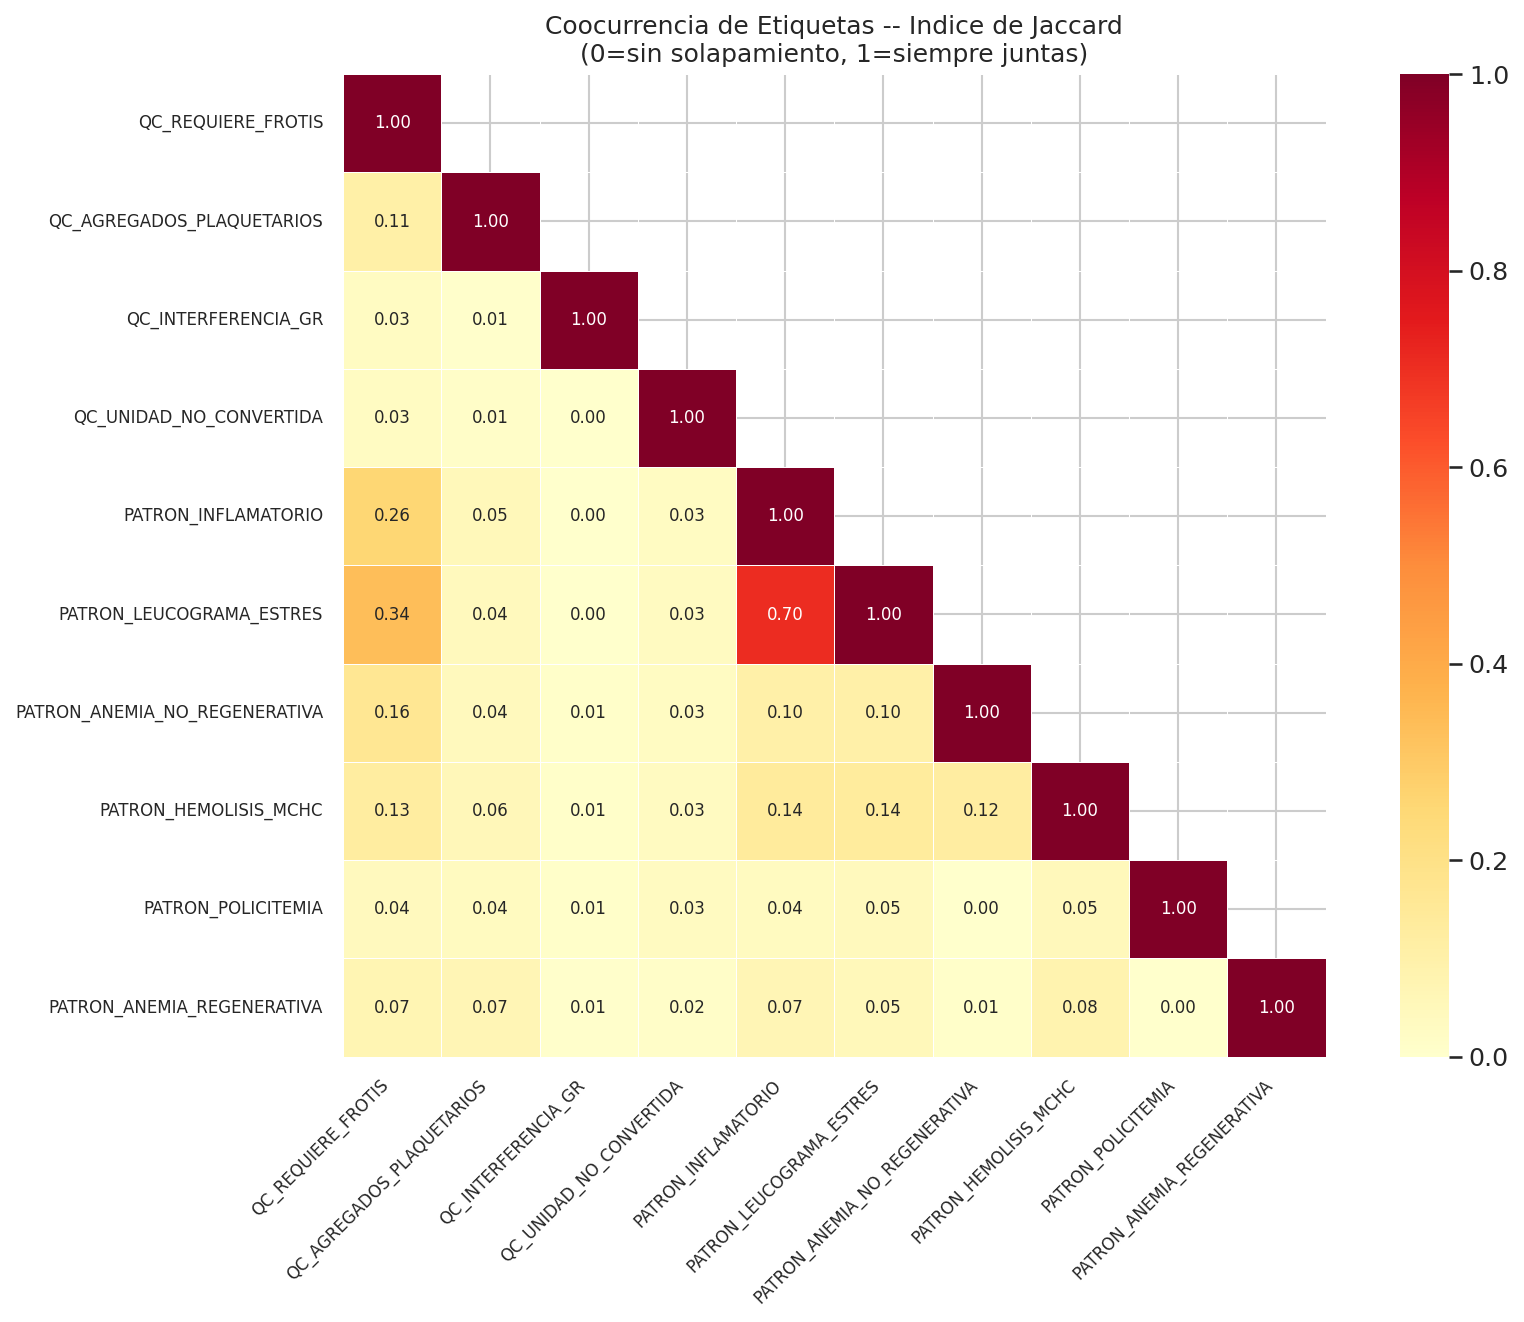

  [Guardada] label_cooccurrence.png


In [9]:
label_cols = list(LABEL_TAXONOMY.keys())
label_matrix = df_idexx[label_cols].astype(float)

# Matriz de coocurrencia normalizada (Jaccard)
n = len(label_cols)
jaccard_matrix = np.zeros((n, n))

for i, la in enumerate(label_cols):
    for j, lb in enumerate(label_cols):
        both = ((label_matrix[la] == 1) & (label_matrix[lb] == 1)).sum()
        either = ((label_matrix[la] == 1) | (label_matrix[lb] == 1)).sum()
        jaccard_matrix[i, j] = both / either if either > 0 else 0.0

jaccard_df = pd.DataFrame(jaccard_matrix, index=label_cols, columns=label_cols)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(jaccard_df, dtype=bool), k=1)
sns.heatmap(
    jaccard_df, mask=mask, annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=1, ax=ax, square=True, linewidths=0.4,
    annot_kws={"size": 8}
)
ax.set_title("Coocurrencia de Etiquetas -- Indice de Jaccard\n(0=sin solapamiento, 1=siempre juntas)",
             fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save_and_show(fig, "label_cooccurrence.png")

### 4.1 Deteccion de pares con alta coocurrencia

In [10]:
# Detectar pares con Jaccard > 0.7 (posible redundancia)
print("Pares con Jaccard > 0.7 (revisar redundancia):")
print("-" * 60)
found = False
for i in range(n):
    for j in range(i+1, n):
        if jaccard_matrix[i][j] > 0.7:
            print(f"  {label_cols[i]} <-> {label_cols[j]}: {jaccard_matrix[i][j]:.2f}")
            found = True
if not found:
    print("  Ninguno -- taxonomia sin redundancias criticas")

Pares con Jaccard > 0.7 (revisar redundancia):
------------------------------------------------------------
  PATRON_INFLAMATORIO <-> PATRON_LEUCOGRAMA_ESTRES: 0.70


---
## 5. Split temporal 70 / 15 / 15

El split temporal es obligatorio para datos clinicos con dependencia temporal.
Un split aleatorio permitiria que el modelo use patrones del futuro para predecir
el pasado, inflando artificialmente las metricas y produciendo un sistema que no
generaliza a hemogramas nuevos.

El corte se realiza sobre `sample_date` de los registros IDEXX ordenados cronologicamente.

In [11]:
df_idexx["sample_date"] = pd.to_datetime(df_idexx["sample_date"], errors="coerce")

# Verificar que no haya nulos en sample_date (prerequisito)
n_null_date = df_idexx["sample_date"].isna().sum()
if n_null_date > 0:
    raise ValueError(f"sample_date tiene {n_null_date} nulos -- resolver antes de hacer el split")

# Ordenar cronologicamente
df_sorted = df_idexx.sort_values("sample_date").reset_index(drop=True)
n = len(df_sorted)

n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

df_train = df_sorted.iloc[:n_train].copy()
df_val   = df_sorted.iloc[n_train : n_train + n_val].copy()
df_test  = df_sorted.iloc[n_train + n_val :].copy()

# Marcar el split
df_train["split"] = "train"
df_val["split"]   = "val"
df_test["split"]  = "test"

print("Split temporal:")
print(f"  Train : {len(df_train):>4} registros | "
      f"{df_train['sample_date'].min().date()} -> {df_train['sample_date'].max().date()}")
print(f"  Val   : {len(df_val):>4} registros | "
      f"{df_val['sample_date'].min().date()} -> {df_val['sample_date'].max().date()}")
print(f"  Test  : {len(df_test):>4} registros | "
      f"{df_test['sample_date'].min().date()} -> {df_test['sample_date'].max().date()}")

Split temporal:
  Train : 1717 registros | 2022-11-24 -> 2025-06-14
  Val   :  368 registros | 2025-06-14 -> 2025-10-24
  Test  :  369 registros | 2025-10-24 -> 2026-02-19


### 5.1 Distribucion de etiquetas por split

In [12]:
print("\nDistribucion de etiquetas por split (% positivos):")
header = f"{'Etiqueta':<40} {'Train':>8} {'Val':>8} {'Test':>8}"
print(header)
print("-" * len(header))
for label in LABEL_TAXONOMY:
    tr = df_train[label].mean() * 100
    vl = df_val[label].mean()   * 100
    te = df_test[label].mean()  * 100
    print(f"  {label:<40} {tr:>7.1f}% {vl:>7.1f}% {te:>7.1f}%")

print("\nNota: Diferencias > 10 puntos porcentuales entre splits requieren ajuste del corte temporal.")


Distribucion de etiquetas por split (% positivos):
Etiqueta                                    Train      Val     Test
-------------------------------------------------------------------
  QC_REQUIERE_FROTIS                          35.0%    35.3%    36.9%
  QC_AGREGADOS_PLAQUETARIOS                    5.5%     4.3%     3.8%
  QC_INTERFERENCIA_GR                          0.9%     1.1%     1.6%
  QC_UNIDAD_NO_CONVERTIDA                      5.2%     0.0%     0.0%
  PATRON_INFLAMATORIO                         44.8%    47.6%    53.7%
  PATRON_LEUCOGRAMA_ESTRES                    44.8%    45.4%    46.6%
  PATRON_ANEMIA_NO_REGENERATIVA                9.5%    12.8%    11.4%
  PATRON_HEMOLISIS_MCHC                       12.6%    21.7%    13.0%
  PATRON_POLICITEMIA                           6.3%     7.3%     8.7%
  PATRON_ANEMIA_REGENERATIVA                   5.1%     4.1%     1.6%

Nota: Diferencias > 10 puntos porcentuales entre splits requieren ajuste del corte temporal.


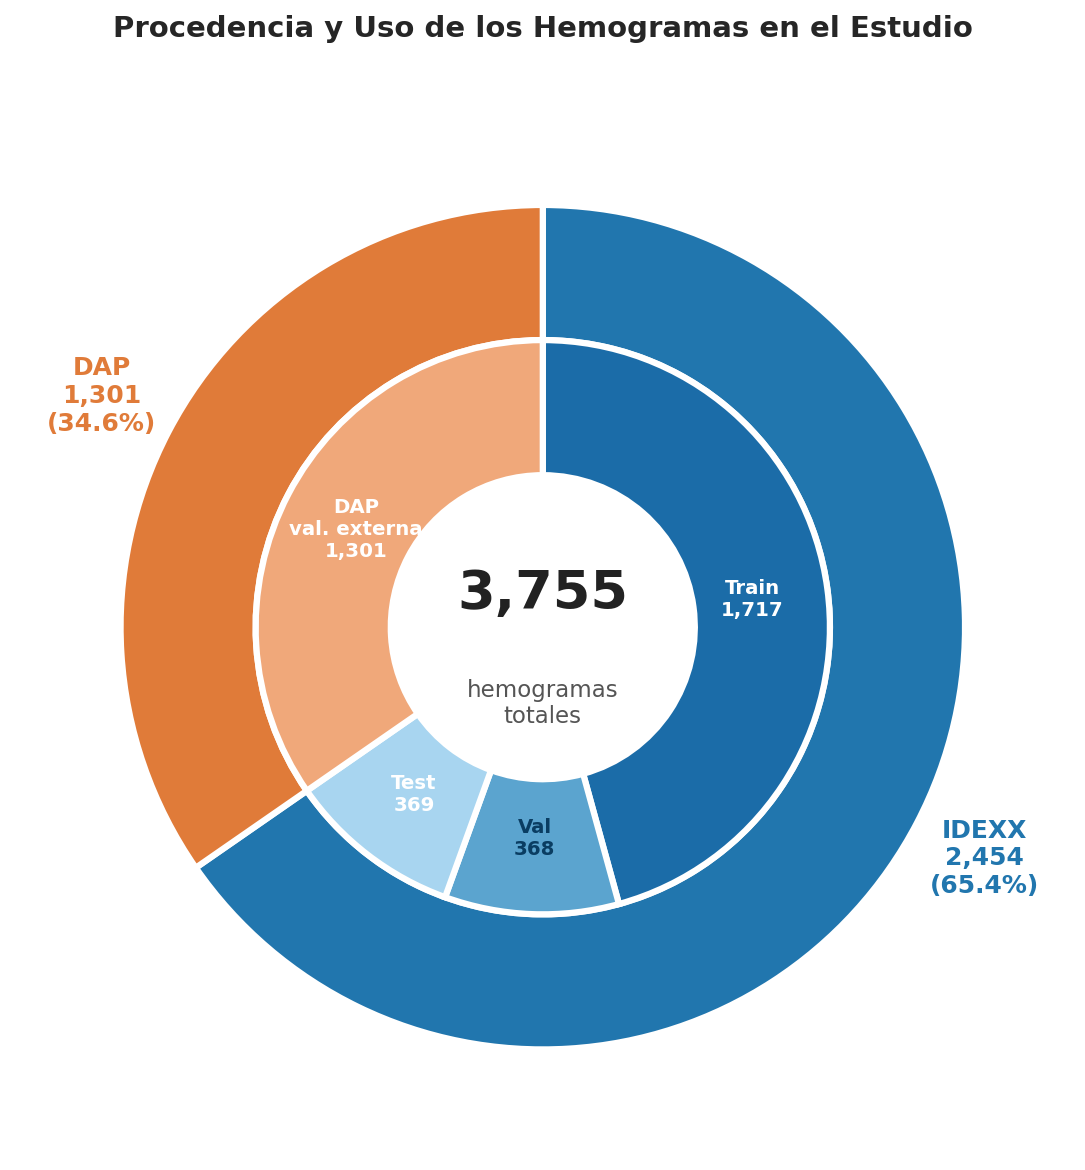

  [Guardada] nb04_fuentes_hemogramas_diapositiva.png


In [13]:
# ── Distribución de fuentes de hemogramas (diapositiva) ──────────────────────
# Donut de dos anillos:
#   Anillo exterior → fuente: IDEXX (entrenamiento) | DAP (validación externa)
#   Anillo interior → uso:    Train | Val | Test     | DAP

N_TOTAL = len(df_full)        # 3,755
N_IDEXX = len(df_idexx)       # 2,454
N_DAP   = len(df_dap)         # 1,301
N_TRAIN = len(df_train)       # 1,717
N_VAL   = len(df_val)         #   368
N_TEST  = len(df_test)        #   369

# ── colores ───────────────────────────────────────────────────────────────────
C_TRAIN = "#1B6CA8"
C_VAL   = "#5BA4CF"
C_TEST  = "#A8D5F0"
C_DAP_O = "#E07B39"   # outer DAP
C_DAP_I = "#F0A87A"   # inner DAP (mismo sector, tono más claro)

fig, ax = plt.subplots(figsize=(11, 8), subplot_kw=dict(aspect="equal"))

# ── anillo exterior: IDEXX vs DAP ─────────────────────────────────────────────
outer_sizes  = [N_IDEXX, N_DAP]
outer_colors = ["#2176AE", C_DAP_O]
outer_wedges, _ = ax.pie(
    outer_sizes,
    radius=1.0,
    colors=outer_colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.32, edgecolor="white", linewidth=3),
)

# ── anillo interior: Train / Val / Test / DAP ─────────────────────────────────
# El sector DAP del anillo interior debe alinearse con el exterior
inner_sizes  = [N_TRAIN, N_VAL, N_TEST, N_DAP]
inner_colors = [C_TRAIN, C_VAL, C_TEST, C_DAP_I]
inner_wedges, _ = ax.pie(
    inner_sizes,
    radius=0.68,
    colors=inner_colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.32, edgecolor="white", linewidth=3),
)

# ── etiquetas en el anillo exterior ───────────────────────────────────────────
for wedge, label, n in zip(outer_wedges,
                            ["IDEXX", "DAP"],
                            [N_IDEXX, N_DAP]):
    ang  = (wedge.theta2 + wedge.theta1) / 2
    rad  = np.deg2rad(ang)
    x    = 1.18 * np.cos(rad)
    y    = 1.18 * np.sin(rad)
    pct  = n / N_TOTAL * 100
    ax.text(x, y,
            f"{label}\n{n:,}\n({pct:.1f}%)",
            ha="center", va="center",
            fontsize=12, fontweight="bold",
            color=wedge.get_facecolor())

# ── etiquetas en el anillo interior ───────────────────────────────────────────
_inner_labels = [
    ("Train",  N_TRAIN),
    ("Val",    N_VAL),
    ("Test",   N_TEST),
    ("DAP\nval. externa", N_DAP),
]
for wedge, (label, n) in zip(inner_wedges, _inner_labels):
    ang = (wedge.theta2 + wedge.theta1) / 2
    rad = np.deg2rad(ang)
    x   = 0.50 * np.cos(rad)
    y   = 0.50 * np.sin(rad)
    pct = n / N_TOTAL * 100
    ax.text(x, y,
            f"{label}\n{n:,}",
            ha="center", va="center",
            fontsize=9.5, fontweight="bold",
            color="white" if label != "Val" else "#0a3d62")

# ── texto central ─────────────────────────────────────────────────────────────
ax.text(0, 0.08, f"{N_TOTAL:,}", ha="center", va="center",
        fontsize=26, fontweight="bold", color="#222222")
ax.text(0, -0.18, "hemogramas\ntotales", ha="center", va="center",
        fontsize=11, color="#555555")

ax.set_title("Procedencia y Uso de los Hemogramas en el Estudio",
             fontsize=14, fontweight="bold", pad=30)

plt.tight_layout()
save_and_show(fig, "nb04_fuentes_hemogramas_diapositiva.png")

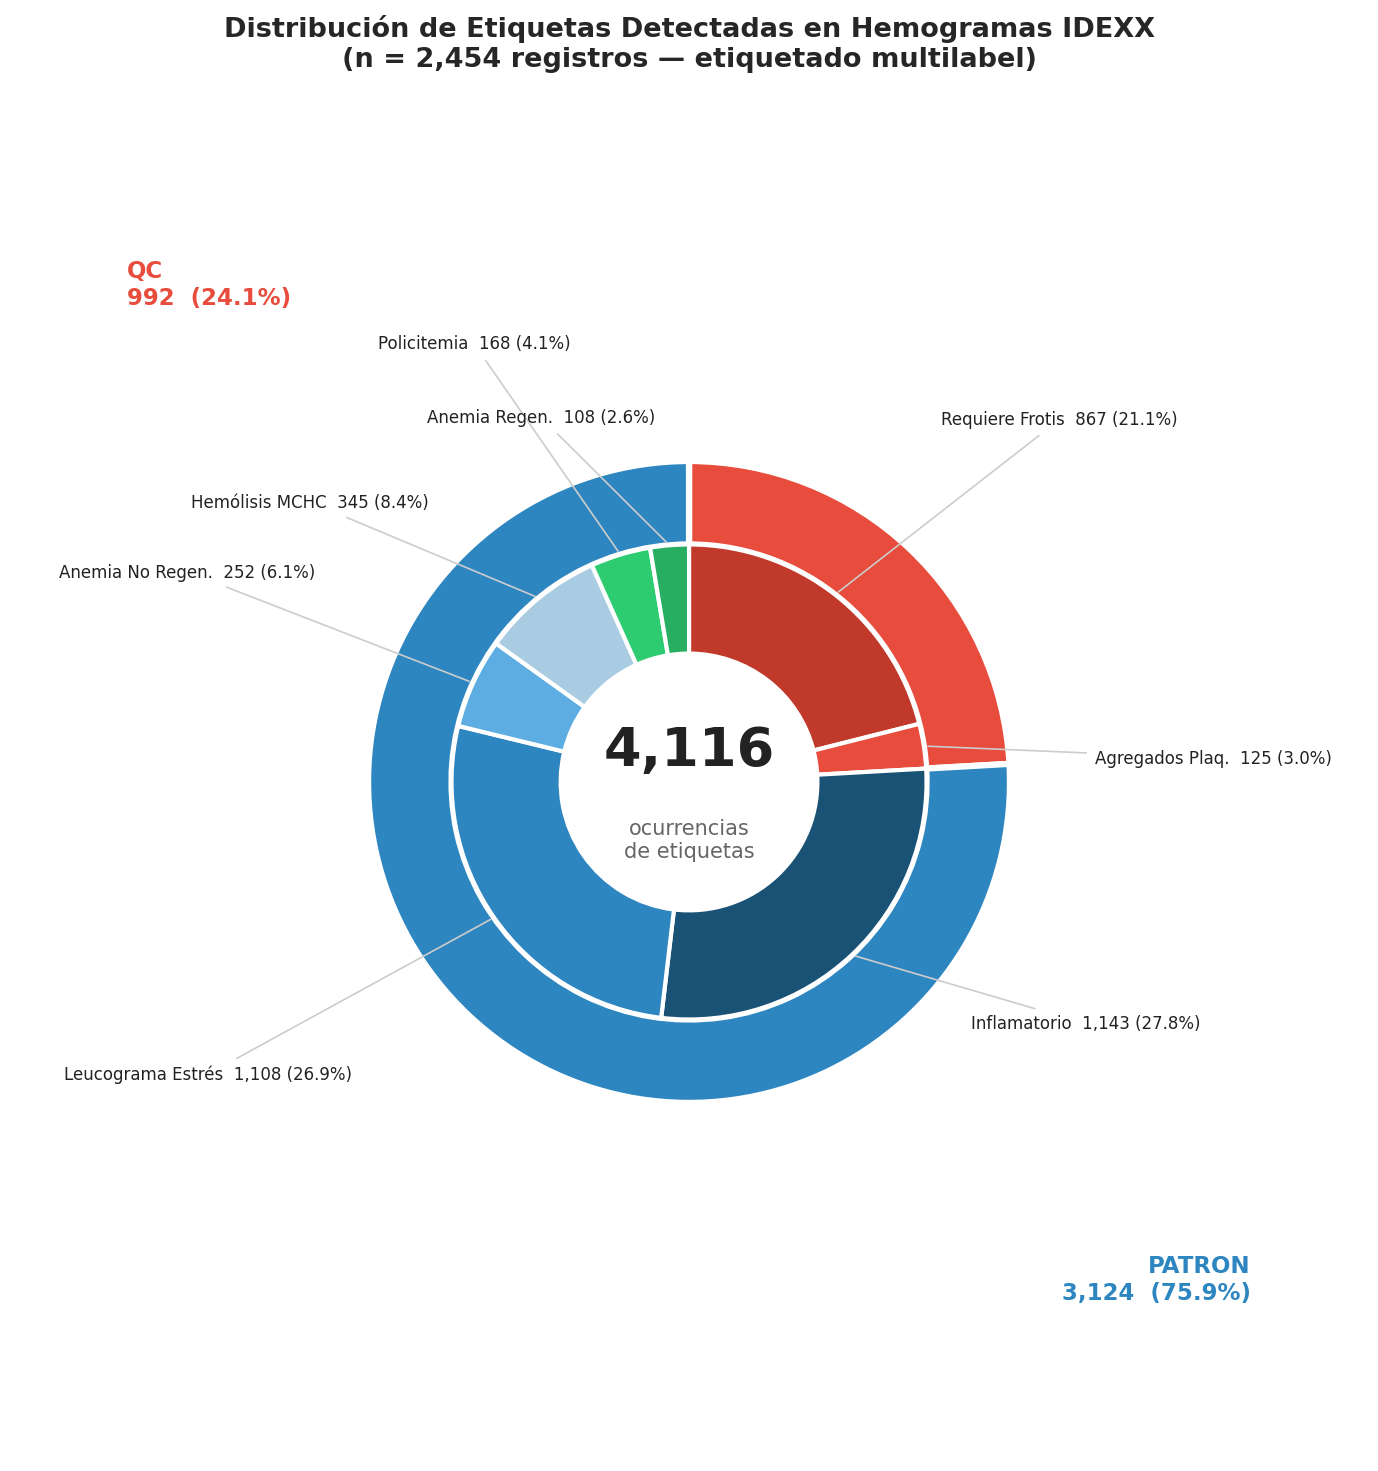

  [Guardada] nb04_etiquetas_donut_diapositiva.png


In [14]:
# ── Donut de etiquetas encontradas en el dataset (diapositiva) ───────────────
_lbl_data = [
    ("Requiere Frotis",   "QC",     int(df_idexx["QC_REQUIERE_FROTIS"].sum())),
    ("Agregados Plaq.",   "QC",     int(df_idexx["QC_AGREGADOS_PLAQUETARIOS"].sum())),
    ("Inflamatorio",      "PATRON", int(df_idexx["PATRON_INFLAMATORIO"].sum())),
    ("Leucograma Estrés", "PATRON", int(df_idexx["PATRON_LEUCOGRAMA_ESTRES"].sum())),
    ("Anemia No Regen.",  "PATRON", int(df_idexx["PATRON_ANEMIA_NO_REGENERATIVA"].sum())),
    ("Hemólisis MCHC",    "PATRON", int(df_idexx["PATRON_HEMOLISIS_MCHC"].sum())),
    ("Policitemia",       "PATRON", int(df_idexx["PATRON_POLICITEMIA"].sum())),
    ("Anemia Regen.",     "PATRON", int(df_idexx["PATRON_ANEMIA_REGENERATIVA"].sum())),
]

_qc_colors     = ["#C0392B", "#E74C3C"]
_patron_colors = ["#1A5276", "#2E86C1", "#5DADE2", "#A9CCE3", "#2ECC71", "#27AE60"]

_inner_colors, _qc_idx, _pat_idx = [], 0, 0
for _, cat, _ in _lbl_data:
    if cat == "QC":
        _inner_colors.append(_qc_colors[_qc_idx % len(_qc_colors)])
        _qc_idx += 1
    else:
        _inner_colors.append(_patron_colors[_pat_idx % len(_patron_colors)])
        _pat_idx += 1

_qc_total     = sum(n for _, cat, n in _lbl_data if cat == "QC")
_patron_total = sum(n for _, cat, n in _lbl_data if cat == "PATRON")
_grand_total  = _qc_total + _patron_total

fig, ax = plt.subplots(figsize=(13, 10), subplot_kw=dict(aspect="equal"))

outer_wedges, _ = ax.pie(
    [_qc_total, _patron_total], radius=1.0,
    colors=["#E74C3C", "#2E86C1"],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.26, edgecolor="white", linewidth=3),
)
inner_wedges, _ = ax.pie(
    [n for _, _, n in _lbl_data], radius=0.74,
    colors=_inner_colors,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.34, edgecolor="white", linewidth=2),
)

# Etiquetas individuales: posición en abanico con offsets para separar vecinos
_y_offsets = [0.12, -0.12, 0.18, -0.18, 0.12, -0.12, 0.14, -0.14]

for i, (wedge, (name, _, n)) in enumerate(zip(inner_wedges, _lbl_data)):
    ang = (wedge.theta2 + wedge.theta1) / 2
    rad = np.deg2rad(ang)
    r   = 1.28
    x   = r * np.cos(rad)
    y   = r * np.sin(rad) + _y_offsets[i]
    pct = n / _grand_total * 100
    ha  = "left" if np.cos(rad) >= 0 else "right"
    ax.annotate(
        f"{name}  {n:,} ({pct:.1f}%)",
        xy=(0.74 * np.cos(rad), 0.74 * np.sin(rad)),
        xytext=(x, y),
        ha=ha, va="center",
        fontsize=8, color="#222222",
        arrowprops=dict(arrowstyle="-", color="#CCCCCC", lw=0.8),
    )

# Etiquetas de categoría: colocadas en los extremos superior e inferior
# QC  → sector izquierdo superior  → esquina sup-izq
# PATRON → sector derecho inferior → esquina inf-der
_cat_positions = [(-1.75, 1.55), (1.75, -1.55)]
_cat_ha        = ["left", "right"]
for (cx, cy), ha, wedge, label, total in zip(
        _cat_positions, _cat_ha,
        outer_wedges, ["QC", "PATRON"], [_qc_total, _patron_total]):
    pct = total / _grand_total * 100
    ax.text(cx, cy,
            f"{label}\n{total:,}  ({pct:.1f}%)",
            ha=ha, va="center",
            fontsize=11, fontweight="bold",
            color=wedge.get_facecolor(),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

# Centro
ax.text(0,  0.10, f"{_grand_total:,}", ha="center", va="center",
        fontsize=26, fontweight="bold", color="#222222")
ax.text(0, -0.18, "ocurrencias\nde etiquetas", ha="center", va="center",
        fontsize=10, color="#666666")

ax.set_title("Distribución de Etiquetas Detectadas en Hemogramas IDEXX\n"
             "(n = 2,454 registros — etiquetado multilabel)",
             fontsize=13, fontweight="bold", pad=20)
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
plt.tight_layout()
save_and_show(fig, "nb04_etiquetas_donut_diapositiva.png")

---
## 6. Visualizacion de distribucion temporal del split

Grafico de barras apiladas mostrando la cantidad de registros por mes y split.
Permite verificar visualmente que el corte temporal es coherente con la distribucion
temporal del dataset.

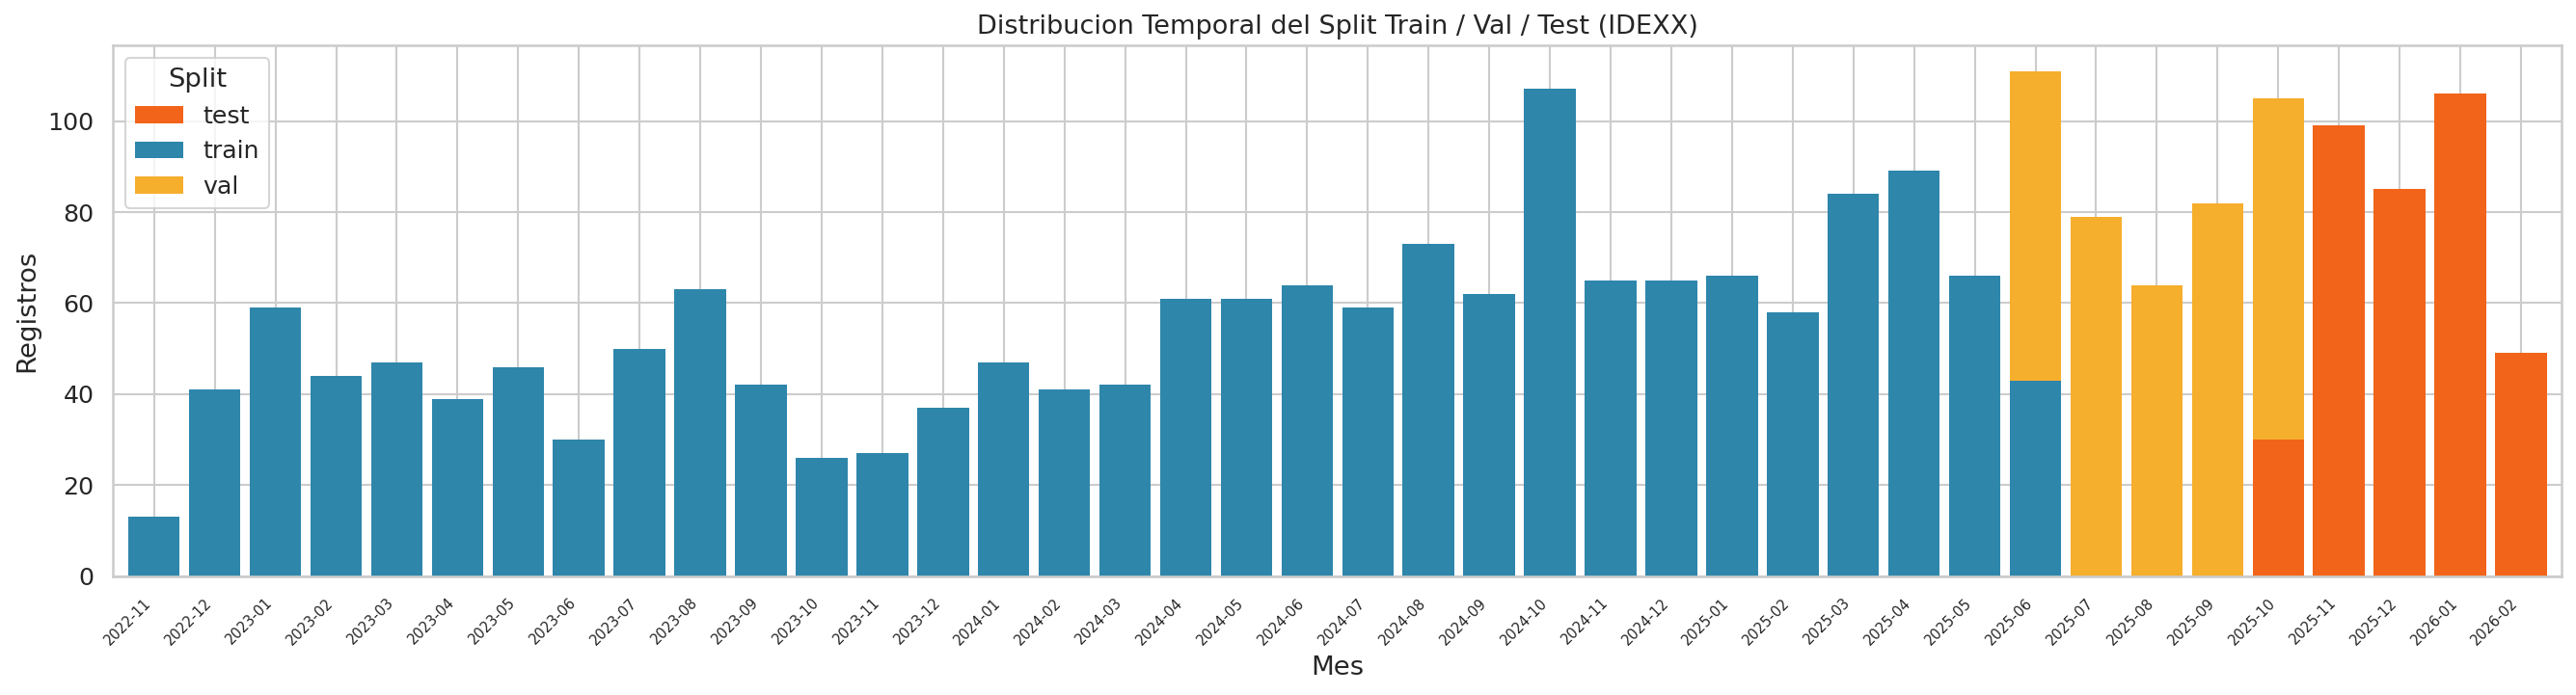

  [Guardada] temporal_split_distribution.png


In [15]:
df_all_splits = pd.concat([df_train, df_val, df_test])
df_all_splits["year_month"] = df_all_splits["sample_date"].dt.to_period("M")

monthly_split = df_all_splits.groupby(["year_month", "split"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 5))
monthly_split.plot(
    kind="bar", stacked=True, ax=ax,
    color={"train": "#2E86AB", "val": "#F6AE2D", "test": "#F26419"},
    width=0.85, edgecolor="none"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Registros")
ax.set_title("Distribucion Temporal del Split Train / Val / Test (IDEXX)", fontsize=13)
ax.legend(title="Split", loc="upper left")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
save_and_show(fig, "temporal_split_distribution.png")

### 6.1 Soporte de etiquetas por split

Barras agrupadas mostrando la cantidad absoluta de positivos por etiqueta
en cada split. Permite detectar desbalances severos entre splits.

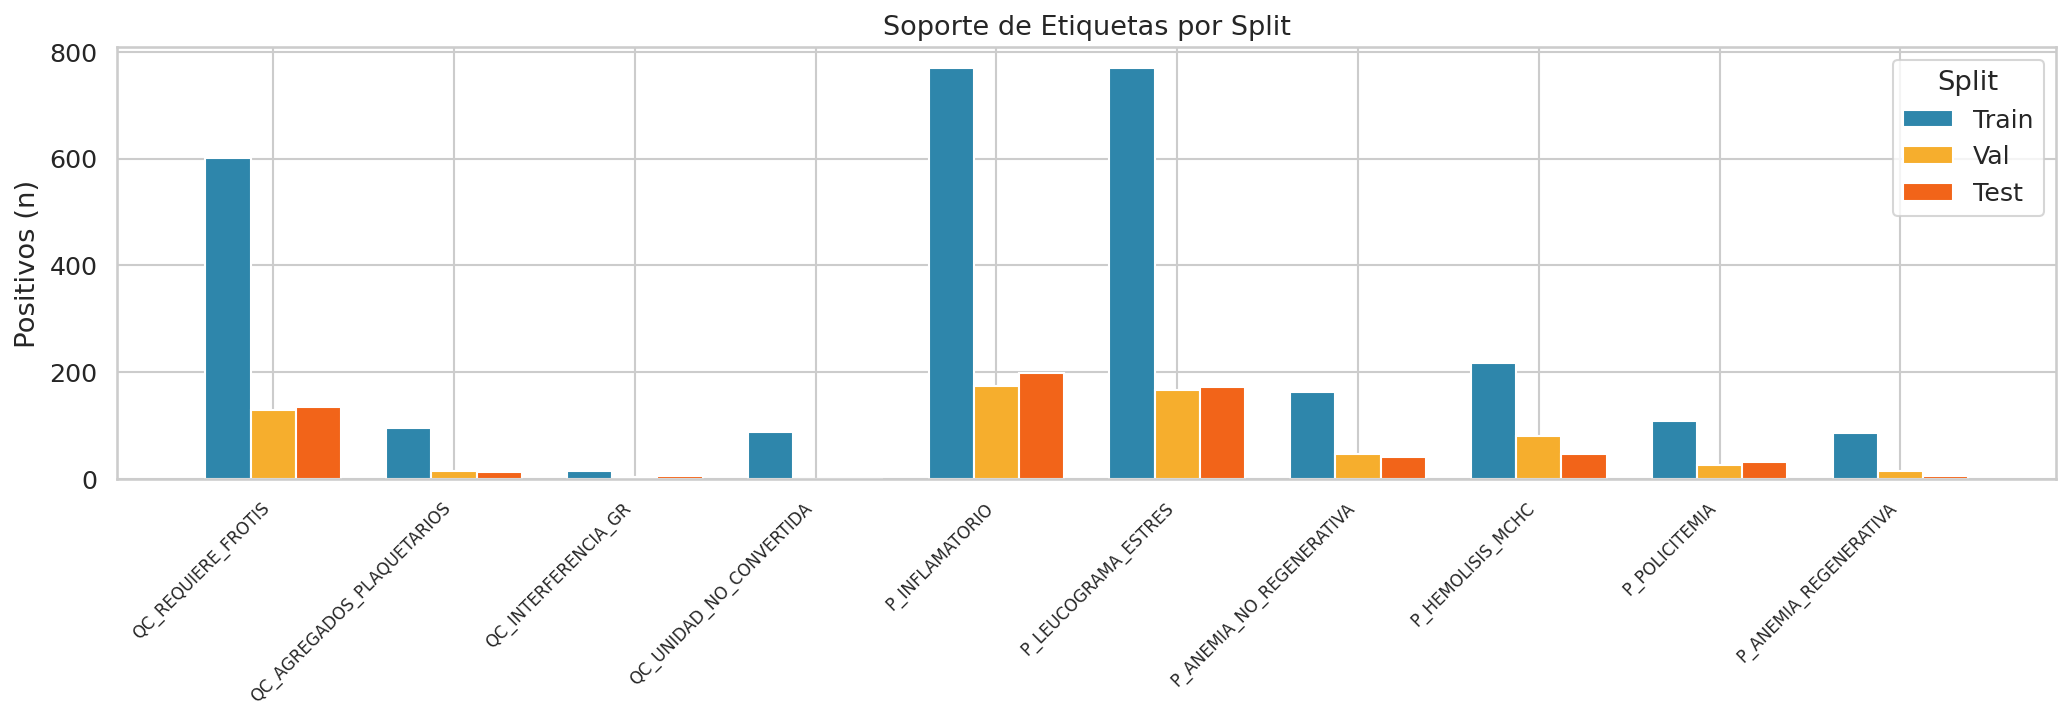

  [Guardada] nb04_label_support_by_split.png


In [16]:
labels_all = list(LABEL_TAXONOMY.keys())
train_support = [int(df_train[l].sum()) for l in labels_all]
val_support   = [int(df_val[l].sum())   for l in labels_all]
test_support  = [int(df_test[l].sum())  for l in labels_all]

x = np.arange(len(labels_all))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, train_support, width, label="Train", color="#2E86AB")
ax.bar(x,         val_support,   width, label="Val",   color="#F6AE2D")
ax.bar(x + width, test_support,  width, label="Test",  color="#F26419")
ax.set_xticks(x)
ax.set_xticklabels([l.replace("PATRON_", "P_") for l in labels_all],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Positivos (n)")
ax.set_title("Soporte de Etiquetas por Split", fontsize=13)
ax.legend(title="Split")
plt.tight_layout()
save_and_show(fig, "nb04_label_support_by_split.png")

### 6.2 Desbalance de clases (ratio negativo:positivo en train)

Un ratio alto indica que la clase positiva es muy minoritaria.
Ratios > 10:1 requieren atencion especial durante el modelado (class_weight,
oversampling, o metricas como PR-AUC en lugar de accuracy).

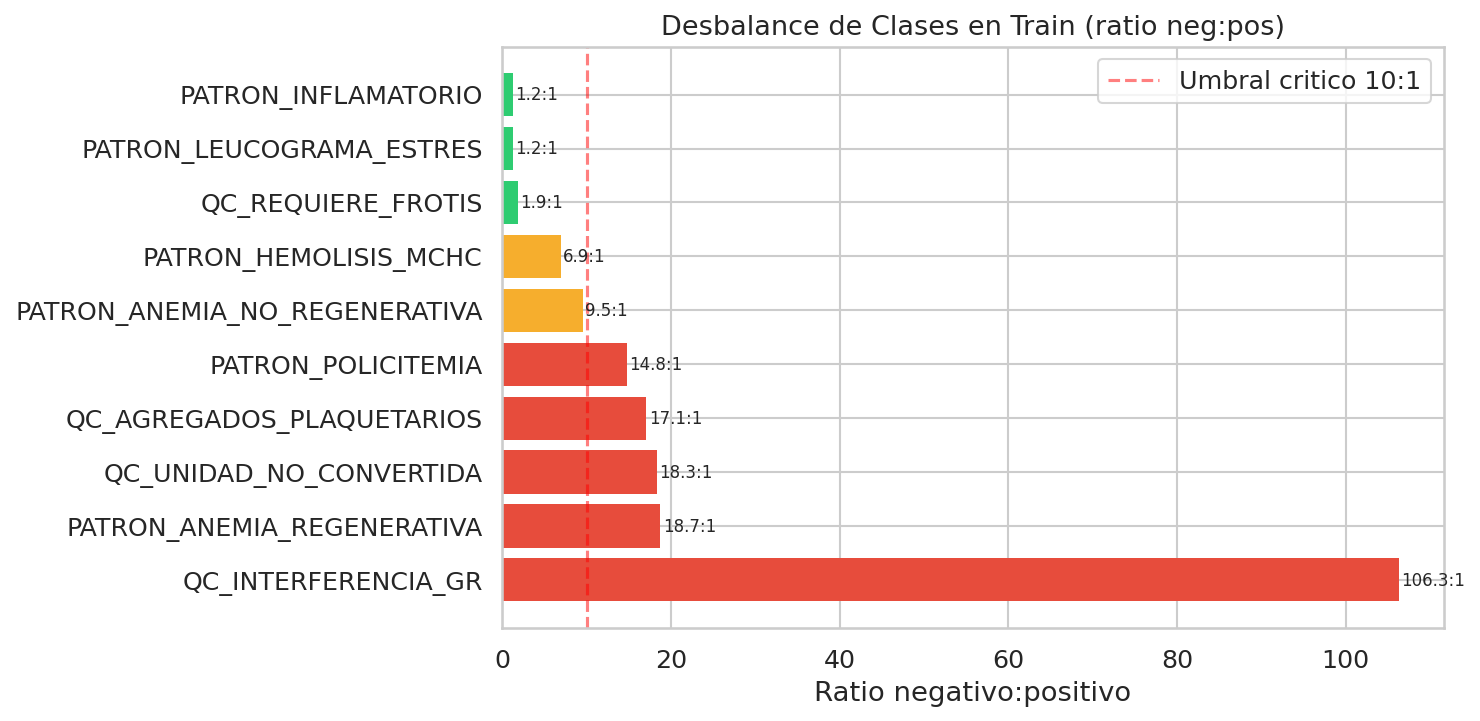

  [Guardada] nb04_desbalance_clases.png


In [17]:
n_train_total = len(df_train)
imbalance_data = []
for label in labels_all:
    n_pos = int(df_train[label].sum())
    n_neg = n_train_total - n_pos
    ratio = n_neg / n_pos if n_pos > 0 else float("inf")
    imbalance_data.append((label, n_pos, n_neg, ratio))

imbalance_data.sort(key=lambda x: x[3], reverse=True)
labels_sorted = [d[0] for d in imbalance_data]
ratios_sorted = [d[3] for d in imbalance_data]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E74C3C" if r > 10 else "#F6AE2D" if r > 5 else "#2ECC71"
          for r in ratios_sorted]
bars = ax.barh(labels_sorted, ratios_sorted, color=colors, edgecolor="none")
ax.set_xlabel("Ratio negativo:positivo")
ax.set_title("Desbalance de Clases en Train (ratio neg:pos)", fontsize=13)
ax.axvline(x=10, color="red", linestyle="--", alpha=0.5, label="Umbral critico 10:1")
ax.legend()
for bar, ratio in zip(bars, ratios_sorted):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{ratio:.1f}:1", va="center", fontsize=8)
plt.tight_layout()
save_and_show(fig, "nb04_desbalance_clases.png")

### 6.3 Distribucion de co-etiquetado

Histograma de cuantas etiquetas tiene cada registro simultaneamente.
Permite evaluar la complejidad del problema multilabel.

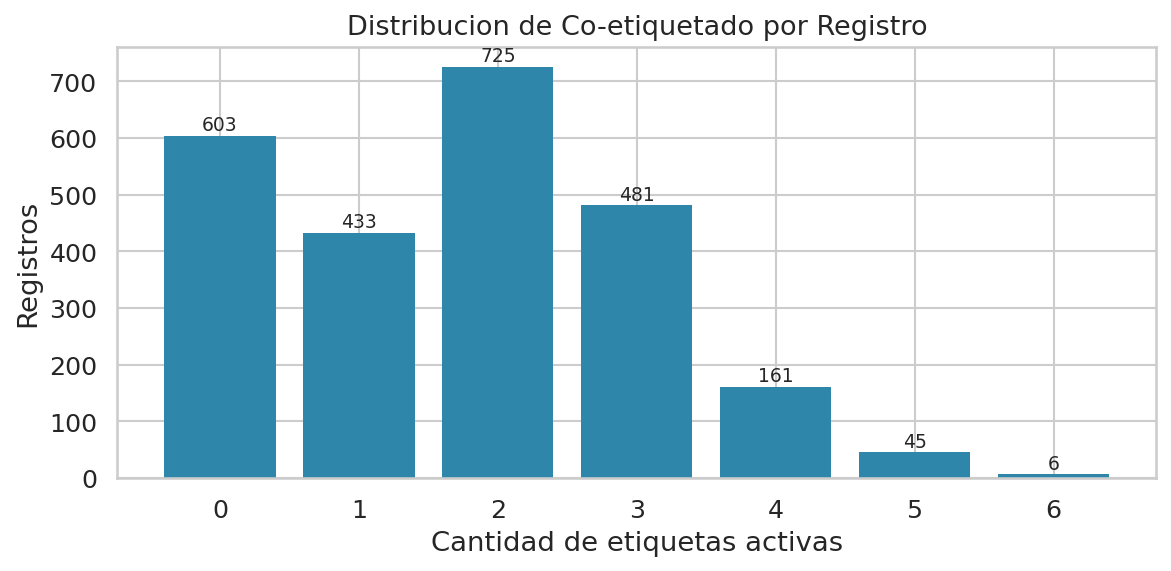

  [Guardada] nb04_coetiquetado_distribucion.png


In [18]:
n_labels = df_idexx[labels_all].sum(axis=1)
counts = n_labels.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index.astype(str), counts.values, color="#2E86AB", edgecolor="none")
for i, (idx, val) in enumerate(counts.items()):
    ax.text(i, val + 10, str(val), ha="center", fontsize=9)
ax.set_xlabel("Cantidad de etiquetas activas")
ax.set_ylabel("Registros")
ax.set_title("Distribucion de Co-etiquetado por Registro", fontsize=13)
plt.tight_layout()
save_and_show(fig, "nb04_coetiquetado_distribucion.png")

---
## 7. Definicion del feature set canonico

Esta seccion define y persiste la lista exacta de columnas que entran al modelo.
Esta lista es la fuente de verdad para el Notebook 05. Ninguna columna puede
anadirse o removerse del feature set sin actualizar este archivo.

Las exclusiones explicitas incluyen:
- Identificadores y PII (patient_name, pet_owner, clinic, etc.)
- Fuente de etiquetas (`idexx_comments` -- incluirlo seria leakage total)
- Leakage temporal (sample_date, date_result)
- Flags del analizador IDEXX (circularidad con targets QC)
- Variables morfologicas DAP (NaN en todos los registros IDEXX)

In [19]:
# CBC raw: valores numericos del hemograma
CBC_RAW_FEATURES = [
    "RBC", "WBC", "Platelets",
    "HGB", "HCT", "MCV", "MCH", "MCHC", "RDW",
    "Reticulocytes", "Reticulocytes_pct",
    "Neutrophils", "Neutrophils_pct",
    "Lymphocytes", "Lymphocytes_pct",
    "Monocytes", "Monocytes_pct",
    "Eosinophils", "Basophils",
    "MPV", "PDW",
]

# Features derivados del NB03
DERIVED_FEATURES = [
    # Flags clinicos -- umbrales hematologicos
    "flag_thrombocytopenia",
    "flag_thrombocytopenia_severe",
    "flag_lymphopenia",
    "flag_lymphocytosis",
    "flag_neutrophilia",
    "flag_neutropenia",
    "flag_leukocytosis",
    "flag_leukopenia",
    "flag_anemia",
    "flag_microcytic",
    "flag_macrocytic",
    "flag_hypochromic",
    "flag_macro_platelets",
    "flag_reticulocytosis_pct_gt2",
    "flag_reticulocytopenia_abs_lt10",
    # Ratios
    "ratio_NLR",
    "ratio_PLR",
    "ratio_MLR",
    "ratio_MPV_PLT",
    # Patron compuesto
    "pattern_stress_leukogram",
    "flag_regen_anemia_proxy",
]

# Variables demograficas
DEMOGRAPHIC_FEATURES = ["age_years"]

# Feature set completo
ALL_FEATURES = CBC_RAW_FEATURES + DERIVED_FEATURES + DEMOGRAPHIC_FEATURES

print(f"Feature set canonico:")
print(f"  CBC raw        : {len(CBC_RAW_FEATURES)} features")
print(f"  Derivados      : {len(DERIVED_FEATURES)} features")
print(f"  Demograficos   : {len(DEMOGRAPHIC_FEATURES)} features")
print(f"  TOTAL          : {len(ALL_FEATURES)} features")

Feature set canonico:
  CBC raw        : 19 features
  Derivados      : 18 features
  Demograficos   : 1 features
  TOTAL          : 38 features


### 7.1 Verificacion de disponibilidad en el dataset

In [ ]:
# Derivados especificos de reticulocitos para anemia regenerativa
# Se calculan desde valores CBC numericos, no desde flags textuales del analizador.
df_idexx["Reticulocytes"] = pd.to_numeric(df_idexx["Reticulocytes"], errors="coerce")
df_idexx["Reticulocytes_pct"] = pd.to_numeric(df_idexx["Reticulocytes_pct"], errors="coerce")
df_idexx["flag_reticulocytosis_pct_gt2"] = (df_idexx["Reticulocytes_pct"] > 2.0).astype(int)
df_idexx["flag_reticulocytopenia_abs_lt10"] = (df_idexx["Reticulocytes"] < 10.0).astype(int)
df_idexx["flag_regen_anemia_proxy"] = (
    (df_idexx["HCT"] < 37.0) & (df_idexx["Reticulocytes_pct"] > 2.0)
).astype(int)

for _split_df in (df_train, df_val, df_test):
    _split_df["Reticulocytes"] = pd.to_numeric(_split_df["Reticulocytes"], errors="coerce")
    _split_df["Reticulocytes_pct"] = pd.to_numeric(_split_df["Reticulocytes_pct"], errors="coerce")
    _split_df["flag_reticulocytosis_pct_gt2"] = (_split_df["Reticulocytes_pct"] > 2.0).astype(int)
    _split_df["flag_reticulocytopenia_abs_lt10"] = (_split_df["Reticulocytes"] < 10.0).astype(int)
    _split_df["flag_regen_anemia_proxy"] = (
        (_split_df["HCT"] < 37.0) & (_split_df["Reticulocytes_pct"] > 2.0)
    ).astype(int)

print("Features de reticulocitos agregados:")
for _feature in ["Reticulocytes", "Reticulocytes_pct", "flag_reticulocytosis_pct_gt2", "flag_reticulocytopenia_abs_lt10", "flag_regen_anemia_proxy"]:
    print(f"  {_feature:<35} train_notna={df_train[_feature].notna().sum()}/{len(df_train)}")


In [20]:
# Verificar disponibilidad en el dataset
available = [f for f in ALL_FEATURES if f in df_idexx.columns]
missing    = [f for f in ALL_FEATURES if f not in df_idexx.columns]

print(f"\nFeatures disponibles : {len(available)}")
print(f"Features faltantes   : {len(missing)}")
if missing:
    print(f"  FALTANTES: {missing}")

# Verificar completitud en train
train_completeness = df_train[available].notna().mean().sort_values()
print("\nFeatures con <90% completitud en train:")
low = train_completeness[train_completeness < 0.90]
if len(low) > 0:
    for feat, pct in low.items():
        print(f"  {feat:<30} {pct*100:.1f}%")
else:
    print("  Todos los features tienen >=90% completitud")


Features disponibles : 38
Features faltantes   : 0

Features con <90% completitud en train:
  age_years                      71.2%


### 7.2 Exclusiones explicitas

In [21]:
# EXCLUSIONES EXPLICITAS -- documentadas aqui para trazabilidad
EXCLUDED_COLUMNS = {
    # Identificadores y PII
    "record_uuid": "identificador unico -- no informativo para el modelo",
    "patient_name": "PII -- dato de privacidad",
    "pet_owner":    "PII -- dato de privacidad",
    "attending_vet": "PII -- dato de privacidad",
    "clinic":       "PII -- dato de privacidad",
    "pdf_filename": "metadato operacional",
    "page_number":  "metadato operacional",
    # Fuente de las etiquetas -- no puede ser feature
    "idexx_comments": "fuente de etiquetas -- incluirlo seria leakage total",
    # Leakage temporal
    "sample_date": "usado solo para el split -- no puede ser feature",
    "date_receipt": "redundante con sample_date",
    "date_result":  "posterior a la muestra -- leakage temporal",
    # Leakage de origen
    "source_dataset": "identifica la fuente -- el modelo no debe usar esto",
}

# Flags del analizador IDEXX -- circularidad con targets
analyzer_flags = [c for c in df_idexx.columns if c.endswith("_flag")]
for flag_col in analyzer_flags:
    EXCLUDED_COLUMNS[flag_col] = "flag H/L del analizador -- circularidad con QC targets"

# Variables morfologicas DAP -- NaN en todos los registros IDEXX
morph_cols = [c for c in df_idexx.columns if c.startswith("morph_")]
for morph_col in morph_cols:
    EXCLUDED_COLUMNS[morph_col] = "morfologia DAP -- NaN en IDEXX, solo para validacion externa"

print(f"Columnas explicitamente excluidas del entrenamiento: {len(EXCLUDED_COLUMNS)}")
print("\nPrimeras 10 exclusiones:")
for i, (col, reason) in enumerate(list(EXCLUDED_COLUMNS.items())[:10]):
    print(f"  {col:<25} -> {reason}")
print(f"  ... ({len(EXCLUDED_COLUMNS)-10} mas)")

Columnas explicitamente excluidas del entrenamiento: 35

Primeras 10 exclusiones:
  record_uuid               -> identificador unico -- no informativo para el modelo
  patient_name              -> PII -- dato de privacidad
  pet_owner                 -> PII -- dato de privacidad
  attending_vet             -> PII -- dato de privacidad
  clinic                    -> PII -- dato de privacidad
  pdf_filename              -> metadato operacional
  page_number               -> metadato operacional
  idexx_comments            -> fuente de etiquetas -- incluirlo seria leakage total
  sample_date               -> usado solo para el split -- no puede ser feature
  date_receipt              -> redundante con sample_date
  ... (25 mas)


---
## 8. Imputacion de valores faltantes

La imputacion se ajusta exclusivamente sobre el split de entrenamiento y se aplica
sobre val y test. Calcular la mediana sobre el dataset completo antes del split
constituye data leakage.

Usamos `SimpleImputer` con estrategia `median` (robusta a outliers clinicos).

In [22]:
# Separar features y targets en cada split
label_cols_oficial = [
    label for label, meta in LABEL_TAXONOMY.items()
    if meta["resultado_oficial"]
]

X_train = df_train[available].copy()
X_val   = df_val[available].copy()
X_test  = df_test[available].copy()

y_train = df_train[label_cols_oficial].copy()
y_val   = df_val[label_cols_oficial].copy()
y_test  = df_test[label_cols_oficial].copy()

print(f"Features para entrenamiento: {len(available)}")
print(f"Etiquetas oficiales: {len(label_cols_oficial)}")
print("\nEtiquetas oficiales:")
for lbl in label_cols_oficial:
    print(f"  {lbl}")

Features para entrenamiento: 38
Etiquetas oficiales: 8

Etiquetas oficiales:
  QC_REQUIERE_FROTIS
  QC_AGREGADOS_PLAQUETARIOS
  PATRON_INFLAMATORIO
  PATRON_LEUCOGRAMA_ESTRES
  PATRON_ANEMIA_NO_REGENERATIVA
  PATRON_HEMOLISIS_MCHC
  PATRON_POLICITEMIA
  PATRON_ANEMIA_REGENERATIVA


### 8.1 Ajuste del imputer en train y aplicacion en val/test

In [23]:
# Imputar con mediana (robusta a outliers clinicos)
# Ajustar SOLO sobre train
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=available, index=X_train.index
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val),
    columns=available, index=X_val.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=available, index=X_test.index
)

print("Imputacion completada:")
print(f"  Train nulos antes  : {X_train.isna().sum().sum():,}")
print(f"  Train nulos despues: {X_train_imp.isna().sum().sum():,}")
print(f"  Val   nulos despues: {X_val_imp.isna().sum().sum():,}")
print(f"  Test  nulos despues: {X_test_imp.isna().sum().sum():,}")

Imputacion completada:
  Train nulos antes  : 812
  Train nulos despues: 0
  Val   nulos despues: 0
  Test  nulos despues: 0


### 8.2 Guardado de estadisticas del imputer

In [24]:
# Guardar estadisticas del imputer para reproducibilidad
imputer_stats = pd.DataFrame({
    "feature": available,
    "mediana_train": imputer.statistics_
})
imputer_stats.to_csv(DATA_PROCESSED / "imputer_medians.csv", index=False)
print(f"\nMedianas del imputer guardadas en: {DATA_PROCESSED / 'imputer_medians.csv'}")
print("\nPrimeras 10 medianas:")
print(imputer_stats.head(10).to_string(index=False))


Medianas del imputer guardadas en: /home/edwinb/tesis/hemogramas-proyectoICC/data/processed/imputer_medians.csv

Primeras 10 medianas:
    feature  mediana_train
        RBC           6.91
        WBC          12.64
  Platelets         338.00
        HGB          17.30
        HCT          49.20
        MCV          71.70
        MCH          25.20
       MCHC          35.10
        RDW          17.50
Neutrophils           8.45


---
## 9. Guardado de los splits y artefactos de configuracion

Los splits se guardan con features imputados, etiquetas, y metadata minima
(record_uuid, sample_date, split) para trazabilidad.

In [25]:
# Reconstruir DataFrames completos con etiquetas y metadata minima
METADATA_COLS = ["record_uuid", "sample_date", "split"]

def build_split_output(X_imp, y, df_orig, metadata_cols):
    """Combina features imputados, etiquetas y metadata para el split."""
    meta = df_orig[[c for c in metadata_cols if c in df_orig.columns]].reset_index(drop=True)
    X_reset = X_imp.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)
    return pd.concat([meta, X_reset, y_reset], axis=1)

train_out = build_split_output(X_train_imp, y_train, df_train, METADATA_COLS)
val_out   = build_split_output(X_val_imp,   y_val,   df_val,   METADATA_COLS)
test_out  = build_split_output(X_test_imp,  y_test,  df_test,  METADATA_COLS)

train_out.to_csv(DATA_PROCESSED / "train.csv", index=False)
val_out.to_csv(DATA_PROCESSED   / "val.csv",   index=False)
test_out.to_csv(DATA_PROCESSED  / "test.csv",  index=False)

print("Splits guardados:")
print(f"  train.csv : {len(train_out):,} registros x {len(train_out.columns)} columnas")
print(f"  val.csv   : {len(val_out):,} registros x {len(val_out.columns)} columnas")
print(f"  test.csv  : {len(test_out):,} registros x {len(test_out.columns)} columnas")

Splits guardados:
  train.csv : 1,717 registros x 49 columnas
  val.csv   : 368 registros x 49 columnas
  test.csv  : 369 registros x 49 columnas


### 9.1 Dataset IDEXX completo con etiquetas

In [26]:
# Dataset IDEXX completo con etiquetas (sin split, para referencia)
labeled_output_cols = METADATA_COLS + available + list(LABEL_TAXONOMY.keys())
df_idexx[[c for c in labeled_output_cols if c in df_idexx.columns]].to_csv(
    DATA_PROCESSED / "labeled_idexx.csv", index=False
)
print(f"\nDataset completo etiquetado:")
print(f"  labeled_idexx.csv : {len(df_idexx):,} registros")


Dataset completo etiquetado:
  labeled_idexx.csv : 2,454 registros


### 9.2 Artefactos de configuracion

In [27]:
# --- Artefactos de configuracion ---

# Lista canonica de features
feature_config = {
    "version": "1.0",
    "timestamp": datetime.now().isoformat(),
    "feature_columns": available,
    "n_features": len(available),
    "cbc_raw": CBC_RAW_FEATURES,
    "derived": DERIVED_FEATURES,
    "demographic": DEMOGRAPHIC_FEATURES,
}
with open(DATA_PROCESSED / "feature_columns.json", "w") as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)

# Taxonomia de etiquetas
label_config = {
    "version": "1.0",
    "timestamp": datetime.now().isoformat(),
    "all_labels": list(LABEL_TAXONOMY.keys()),
    "official_labels": label_cols_oficial,
    "excluded_labels": [
        l for l, m in LABEL_TAXONOMY.items() if not m["resultado_oficial"]
    ],
    "marginal_labels": [
        l for l, m in LABEL_TAXONOMY.items()
        if m.get("soporte_limitado") and m["resultado_oficial"]
    ],
    "taxonomy": {
        label: {
            "categoria": meta["categoria"],
            "descripcion": meta["descripcion"],
            "resultado_oficial": meta["resultado_oficial"],
        }
        for label, meta in LABEL_TAXONOMY.items()
    }
}
with open(DATA_PROCESSED / "label_columns.json", "w") as f:
    json.dump(label_config, f, indent=2, ensure_ascii=False)

# Distribucion de etiquetas
dist_stats = {}
for label in LABEL_TAXONOMY:
    if label not in df_idexx.columns:
        continue
    dist_stats[label] = {
        "total": int(df_idexx[label].sum()),
        "pct_total": round(float(df_idexx[label].mean() * 100), 2),
        "train": int(df_train[label].sum()),
        "val":   int(df_val[label].sum()),
        "test":  int(df_test[label].sum()),
        "resultado_oficial": LABEL_TAXONOMY[label]["resultado_oficial"],
    }
with open(DATA_PROCESSED / "label_distribution.json", "w") as f:
    json.dump(dist_stats, f, indent=2, ensure_ascii=False)

print("\nArtefactos de configuracion guardados:")
print("  feature_columns.json")
print("  label_columns.json")
print("  label_distribution.json")


Artefactos de configuracion guardados:
  feature_columns.json
  label_columns.json
  label_distribution.json


---
## 10. Verificacion de integridad y checklist de cierre

Verificamos que todos los criterios de integridad del dataset preparado se cumplen
antes de proceder al Notebook 05.

In [28]:
print("=" * 70)
print("  VERIFICACION FINAL -- Notebook 04")
print("=" * 70)

checks = []

# 1. Splits sin solapamiento temporal
train_max = df_train["sample_date"].max()
val_min   = df_val["sample_date"].min()
val_max   = df_val["sample_date"].max()
test_min  = df_test["sample_date"].min()
no_overlap = (val_min >= train_max) and (test_min >= val_max)
checks.append(("Sin solapamiento temporal entre splits", no_overlap))

# 2. Sin leakage: idexx_comments no esta en X
no_comment_leak = "idexx_comments" not in available
checks.append(("idexx_comments excluido de features", no_comment_leak))

# 3. Sin leakage: flags del analizador no estan en X
analyzer_flags = [c for c in df_idexx.columns if c.endswith("_flag")]
no_flag_leak = not any(f in available for f in analyzer_flags)
checks.append(("Flags del analizador excluidos de features", no_flag_leak))

# 4. Etiquetas oficiales tienen soporte >15 en test
low_support = [
    l for l in label_cols_oficial
    if df_test[l].sum() < 15 and l not in [m for m in label_cols_oficial if LABEL_TAXONOMY[m].get("soporte_limitado")]
]
sufficient_support = len(low_support) == 0
checks.append(("Etiquetas oficiales no marginales con soporte >15 en test", sufficient_support))
if not sufficient_support:
    print(f"  ATENCION: Etiquetas con soporte bajo en test: {low_support}")

# 5. Sin nulos en features imputados
no_nulls = (X_train_imp.isna().sum().sum() == 0 and
            X_val_imp.isna().sum().sum()   == 0 and
            X_test_imp.isna().sum().sum()  == 0)
checks.append(("Sin nulos en features tras imputacion", no_nulls))

# 6. Artefactos de configuracion presentes
artifacts = ["feature_columns.json", "label_columns.json",
             "label_distribution.json", "imputer_medians.csv"]
all_artifacts = all((DATA_PROCESSED / a).exists() for a in artifacts)
checks.append(("Todos los artefactos de configuracion guardados", all_artifacts))

# Reporte
print(f"\n{'Criterio':<55} {'Estado':>8}")
print("-" * 70)
all_pass = True
for desc, passed in checks:
    status = "OK" if passed else "FALLA"
    if not passed:
        all_pass = False
    print(f"  {desc:<53} [{status}]")

print()
if all_pass:
    print("  Notebook 04 completado. Dataset listo para Notebook 05.")
else:
    print("  ATENCION: Resolver los criterios marcados antes de continuar.")

print("=" * 70)

  VERIFICACION FINAL -- Notebook 04
  ATENCION: Etiquetas con soporte bajo en test: ['QC_AGREGADOS_PLAQUETARIOS', 'PATRON_ANEMIA_REGENERATIVA']

Criterio                                                  Estado
----------------------------------------------------------------------
  Sin solapamiento temporal entre splits                [OK]
  idexx_comments excluido de features                   [OK]
  Flags del analizador excluidos de features            [OK]
  Etiquetas oficiales con soporte >15 en test           [FALLA]
  Sin nulos en features tras imputacion                 [OK]
  Todos los artefactos de configuracion guardados       [OK]

  ATENCION: Resolver los criterios marcados antes de continuar.


---
## 11. Resumen y proximos pasos

In [29]:
print("=" * 70)
print("  RESUMEN -- Notebook 04: Etiquetado y Preparacion")
print("=" * 70)
print()
print(f"  Dataset de entrada : featured_raw.csv ({len(df_full):,} registros)")
print(f"  Dataset IDEXX      : {len(df_idexx):,} registros etiquetados")
print(f"  Dataset DAP        : {len(df_dap):,} registros reservados para validacion externa")
print()
print(f"  Etiquetas totales  : {len(LABEL_TAXONOMY)}")
print(f"  Etiquetas oficiales: {len(label_cols_oficial)}")
print(f"  Features entrenamiento: {len(available)}")
print()
print("  Splits temporales:")
print(f"    Train : {len(df_train):>4} registros")
print(f"    Val   : {len(df_val):>4} registros")
print(f"    Test  : {len(df_test):>4} registros")
print()
print("  Outputs:")
print("    data/processed/labeled_idexx.csv")
print("    data/processed/train.csv")
print("    data/processed/val.csv")
print("    data/processed/test.csv")
print("    data/processed/feature_columns.json")
print("    data/processed/label_columns.json")
print("    data/processed/label_distribution.json")
print("    data/processed/imputer_medians.csv")
print("    outputs/label_cooccurrence.png")
print("    outputs/temporal_split_distribution.png")
print("    outputs/nb04_label_support_by_split.png")
print("    outputs/nb04_desbalance_clases.png")
print("    outputs/nb04_coetiquetado_distribucion.png")
print()
print("  Siguiente -> Notebook 05: Modelado (BalancedRF + XGBoost multilabel)")
print("=" * 70)

  RESUMEN -- Notebook 04: Etiquetado y Preparacion

  Dataset de entrada : featured_raw.csv (3,755 registros)
  Dataset IDEXX      : 2,454 registros etiquetados
  Dataset DAP        : 1,301 registros reservados para validacion externa

  Etiquetas totales  : 10
  Etiquetas oficiales: 8
  Features entrenamiento: 38

  Splits temporales:
    Train : 1717 registros
    Val   :  368 registros
    Test  :  369 registros

  Outputs:
    data/processed/labeled_idexx.csv
    data/processed/train.csv
    data/processed/val.csv
    data/processed/test.csv
    data/processed/feature_columns.json
    data/processed/label_columns.json
    data/processed/label_distribution.json
    data/processed/imputer_medians.csv
    outputs/label_cooccurrence.png
    outputs/temporal_split_distribution.png
    outputs/nb04_label_support_by_split.png
    outputs/nb04_desbalance_clases.png
    outputs/nb04_coetiquetado_distribucion.png

  Siguiente -> Notebook 05: Modelado (BalancedRF + XGBoost multilabel)
